# Chapter 27: The Mathematics of Delegation

A controller reaches the edge of its authority and asks for review. That is often the correct action, but delegation does not make the remaining work disappear. A reviewer has finite service capacity, and a growing queue can consume the deadline before approval arrives.

This notebook combines an authority handoff predicate with a simple review queue. It identifies tasks that may proceed autonomously, tasks requiring a review packet, and tasks whose declared mean review time exceeds their deadline. The method keeps review receipt separate from human authority. Its output is a local scheduling and authorization diagnostic, not a sent message or a prediction that a particular reviewer will answer on time.

**Outcome:** Compute a review queue diagnostic and identify required handoff packets and release blockers.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let total arrival rate be lambda and delegated fraction f. Effective review arrival is lambda_review=lambda f. Under an M/M/1 construction with service rate mu, the queue is stable when lambda_review<mu. Mean system time, including service, is W=1/(mu-lambda_review). At or above capacity no finite stationary mean exists, so the output remains unavailable.

A task requires delegation when the agent lacks authority or its declared risk exceeds the autonomous threshold. In this simplified contract, autonomous release requires current agent authority and acceptable risk. Delegated release requires human authority, a received review, and a mean-time diagnostic that does not exceed the task deadline.

The last predicate is deliberately a planning convention, not a pathwise guarantee. Queue mean W is not a measured duration for an individual task. A receipt may in reality arrive earlier or later. The returned flag identifies incompatibility between the declared capacity plan and deadline, and should not be mistaken for evidence that a specific observed review was late.

## A calculation you can run

Supply arrival and service rates in the same time unit, delegated fraction, risk threshold, and task rows. Exact booleans distinguish current agent authority, human authority, and review receipt. Validation requires positive service rate, valid probabilities, and nonnegative deadlines.

The function calculates effective load, stability, and mean sojourn when available. It then emits delegation-required, queue-mean-exceeds-deadline, release, and review-packet-required flags for each task. The sensitivity figure varies review arrivals below service capacity and shows how mean time grows near saturation. In the changed case increase the delegated fraction while preserving total arrivals and service rate. Predict which releases the capacity contract will block.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 27
inputs = {'arrival_rate': 4,
 'service_rate': 3,
 'delegation_fraction': 0.5,
 'agent_risk_limit': 0.1,
 'tasks': [{'name': 'routine',
            'agent_authorized': True,
            'risk': 0.02,
            'deadline': 2,
            'human_authorized': False,
            'review_received': False},
           {'name': 'release',
            'agent_authorized': False,
            'risk': 0.05,
            'deadline': 2,
            'human_authorized': True,
            'review_received': True},
           {'name': 'sensitive',
            'agent_authorized': False,
            'risk': 0.2,
            'deadline': 2,
            'human_authorized': True,
            'review_received': False}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed teaching example

Calculated quantities:
{
  "effective_review_arrival_rate": 2.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "routine",
      "delegation_required": false,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "release",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "sensitive",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": false,
      "released": false,
      "review_packet_required": true
    }
  ],
  "released_count": 2
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected revi

Default review load is 4(0.5)=2, below service rate 3. Mean sojourn is 1/(3-2)=1 time unit. Routine is authorized and below the agent risk limit, so it can proceed autonomously. Release requires delegation but has human authority and a received review, with deadline 2 exceeding the mean diagnostic, so it passes the declared release contract.

Sensitive lacks a received review and requires a packet. With delegated fraction 0.9, review load becomes 3.6, exceeding capacity. The stationary mean is unavailable and delegated release is blocked by the capacity plan. Routine remains autonomous. Review capacity did not change the underlying authority predicate.

The mean-versus-deadline flag is a planning diagnostic, not a probability of meeting the deadline. If the M/M/1 first-come-first-served assumption held exactly, sojourn time would be exponential with rate 3-2=1, so with deadline 2 the chance of meeting it would be 1-exp(-2), about 0.865, even though the mean 1 is below 2. This probability is a hand calculation, not a field the lab reports.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


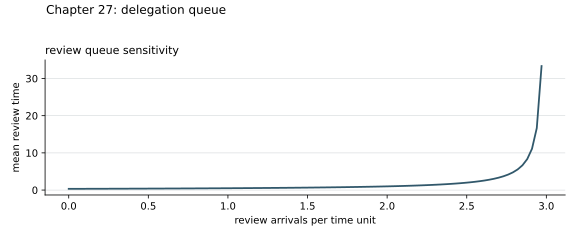

In [3]:
display(SVG(figure_svg(report)))

**Figure 27.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Delegation can fail when it becomes an automatic escape from uncertainty without a capacity model. Sending every doubtful task to a fixed reviewer raises arrival load and can make the queue unstable. The sensitivity curve shows that even stable load near capacity creates large mean delays.

A queue calculation can also be overread. M/M/1 assumes Poisson arrivals, exponential service, one reviewer, and stationary rates. Real review teams may batch work, prioritize cases, or have correlated arrivals. A single mean cannot prove deadline compliance or determine an actual task's elapsed review time.

Authority remains independent. A review receipt from someone without the required permission cannot authorize release. Conversely, the method's mean-time flag is not evidence that an already received review was late. Preserve actual timestamps for empirical deadline checks and use this output as a capacity-design diagnostic.

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "effective_review_arrival_rate": 3.6,
  "queue_stable": false,
  "mean_review_sojourn": null,
  "tasks": [
    {
      "task": "routine",
      "delegation_required": false,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "release",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    },
    {
      "task": "sensitive",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": true
    }
  ],
  "released_count": 1
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when ex

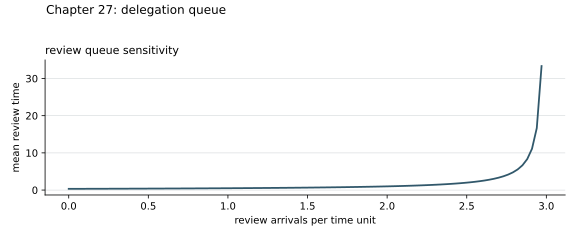

In [4]:
changed_inputs = {'arrival_rate': 4,
 'service_rate': 3,
 'delegation_fraction': 0.9,
 'agent_risk_limit': 0.1,
 'tasks': [{'name': 'routine',
            'agent_authorized': True,
            'risk': 0.02,
            'deadline': 2,
            'human_authorized': False,
            'review_received': False},
           {'name': 'release',
            'agent_authorized': False,
            'risk': 0.05,
            'deadline': 2,
            'human_authorized': True,
            'review_received': True},
           {'name': 'sensitive',
            'agent_authorized': False,
            'risk': 0.2,
            'deadline': 2,
            'human_authorized': True,
            'review_received': False}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 27.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer review load is 1 with service rate 2, so mean sojourn is 1. The task deadline is 0.5, below that planning mean. Despite human authority and a declared receipt, the simplified capacity contract does not approve release. This flags the planning mismatch rather than asserting the actual receipt arrived after 0.5.

For local use, draft a handoff packet containing current state, missing authority, risk, observations, proposed action, and deadline. Do not send it automatically from this computation. Measure real arrival and service patterns before adopting the queue law, and preserve review timestamps when evaluating individual deadline outcomes.

In [5]:
transfer_inputs = {'arrival_rate': 1,
 'service_rate': 2,
 'delegation_fraction': 1,
 'agent_risk_limit': 0.05,
 'tasks': [{'name': 'approval',
            'agent_authorized': False,
            'risk': 0.01,
            'deadline': 0.5,
            'human_authorized': True,
            'review_received': True}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed transfer example

Calculated quantities:
{
  "effective_review_arrival_rate": 1.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "approval",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    }
  ],
  "released_count": 0
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected review capacity is adequate.

Assumptions:
- M/M/1 review queue with Poisson arrivals, exponential service, one reviewer.
- Arrival and service rates use the same time unit.
- Deadline test uses mean queue sojourn as a diagnostic, not a per-task prediction.

Limitations:
- A queue mean does not prove any individual deadline will be met.
- A human review receipt 

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **arrival_rate:** Nonnegative incoming task rate per declared time unit.
- **service_rate:** Positive reviewer service rate in the same unit.
- **delegation_fraction:** Fraction in [0,1] entering review.
- **agent_risk_limit:** Probability threshold in [0,1] for autonomous task handling.
- **tasks:** Rows with name,agent_authorized:boolean,risk:probability,deadline:nonnegative time,human_authorized:boolean,review_received:boolean.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch27.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "effective_review_arrival_rate": 1.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "approval",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    }
  ],
  "released_count": 0
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected review capacity is adequate.

Assumptions:
- M/M/1 review queue with Poisson arrivals, exponential service, one reviewer.
- Arrival and service rates use the same time unit.
- Deadline test uses mean queue sojourn as a diagnostic, not a per-task prediction.

Limitations:
- A queue mean does not prove any individual deadline will b

## Questions

1. Compute default review mean.

2. Why is changed stationary mean unavailable?

3. Does mean 1 prove the transfer receipt arrived after 0.5?

Answers: [separate solutions](../solutions/ch27.md). Try the calculation before opening them.

## Summary

Delegation transfers work to a bounded human service. The notebook calculates conditional queue stability and mean time, then keeps authority and review receipts explicit in a task contract. More delegation can overload review even when it is individually sensible. The changed case exposes saturation; the transfer exposes a deadline-planning mismatch. Queue means support capacity design, while actual deadline compliance requires timestamps and permission requires a valid authority source.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-27-delegation-queue`](../skills/maa-27-delegation-queue/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 27.1

![Equation 27.1](../assets/math/de77306687ec0648e0c4.svg)

Defines current authority as actions permitted by declared grants and satisfied state-specific preconditions.

A high-scoring action absent from this set remains a recommendation, not an executable act.

LaTeX source, preserved for inspection:

```latex
\mathcal A_{\mathrm{auth}}(x)
=\{a\in\mathcal A:\operatorname{Authorized}_{\mathcal G}(a,x)=1,
\;\operatorname{Pre}(a,x)=1\}.
\tag{27.1}
```

### Equation 27.2

![Equation 27.2](../assets/math/7975917fee2d7cc96458.svg)

Routes a zero-one-loss prediction to the classifier or named expert by comparing their conditional chances of correctness.

Deferral begins where expert correctness matches or exceeds the classifier's best class probability, not where confidence merely feels low.

LaTeX source, preserved for inspection:

```latex
\operatorname{route}^{\star}(x)=
\begin{cases}
\operatorname{Del}(E,\Delta), & p_E(x)\geq \max_y p(y\mid x),\\
\arg\max_y p(y\mid x), & p_E(x)<\max_y p(y\mid x).
\end{cases}
\tag{27.2}
```

### Equation 27.3

![Equation 27.3](../assets/math/b6ceb29c5e478c1354a4.svg)

Defines candidate routes and selects an authorized act, named delegation, wait, narrow, or return route by declared route value.

Every maximand is one route `\varrho`, so its value and selected output share one coherent domain.

LaTeX source, preserved for inspection:

```latex
\mathcal R_{\mathrm{auth}}(x)=
\{(\mathrm{act},a),(\mathrm{delegate},d,\Delta),(\mathrm{wait},o,\Delta),(\mathrm{narrow},a'),(\mathrm{return})
\ \text{that are authorized at }x\},
\qquad
\operatorname{choose}^{\star}(x)\in
\arg\max_{\varrho\in\mathcal R_{\mathrm{auth}}(x)}V(\varrho,x).
\tag{27.3}
```

### Equation 27.4

![Equation 27.4](../assets/math/f09c52733cdad330374e.svg)

States a stopping discipline: wait only for a named useful observation, bounded delay, and fallback authorized in every reachable deadline state.

Authority must survive every reachable post-wait state; otherwise delay can leave no permitted next action.

LaTeX source, preserved for inspection:

```latex
\operatorname{wait}^{\star}(o,\Delta,x)
\quad\text{only if}\quad
\operatorname{VOI}(o)>
\operatorname{DelayCost}(\Delta,x)
\quad\text{and}\quad
\operatorname{fallback}(\Delta,x_\Delta)\in\mathcal A_{\mathrm{auth}}(x_\Delta)
\ \text{for every reachable }x_\Delta.
\tag{27.4}
```